In [35]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from tqdm import tqdm
from pathlib import Path
import scipy.io as sio




# ============================================================
# Calculate normalized spatial variability
# ============================================================
def calculate_H_from_local(
    local_values,
    min_valid_blocks
):
    """
    Calculate

        H = std /
            (abs(mean) + rms)

    across spatial blocks.
    """

    local_values = np.asarray(
        local_values,
        dtype=float
    )

    nscale = local_values.shape[0]

    H = np.full(nscale, np.nan)
    mean_value = np.full(nscale, np.nan)
    std_value = np.full(nscale, np.nan)
    rms_value = np.full(nscale, np.nan)
    cancellation_ratio = np.full(nscale, np.nan)

    nvalid_blocks = np.zeros(
        nscale,
        dtype=int
    )

    for ir in range(nscale):

        values = local_values[ir]
        values = values[
            np.isfinite(values)
        ]

        nvalid_blocks[ir] = values.size

        if values.size < min_valid_blocks:
            continue

        mean_value[ir] = np.mean(values)

        std_value[ir] = np.std(
            values,
            ddof=0
        )

        rms_value[ir] = np.sqrt(
            np.mean(values**2)
        )

        denominator = (
            np.abs(mean_value[ir])
            + rms_value[ir]
        )

        if denominator > 0:
            H[ir] = (
                std_value[ir]
                / denominator
            )

        if rms_value[ir] > 0:
            cancellation_ratio[ir] = (
                np.abs(mean_value[ir])
                / rms_value[ir]
            )

    return {
        "H": H,
        "mean": mean_value,
        "std": std_value,
        "rms": rms_value,
        "cancellation_ratio": cancellation_ratio,
        "nvalid_blocks": nvalid_blocks,
    }


# ============================================================
# Eulerian grid-block structure functions and H metrics
# ============================================================
def calculate_eulerian_homogeneity(
    u,
    v,
    r_values,
    dx,
    dy=None,
    nblock_y=4,
    nblock_x=4,
    periodic=False,
    directions=None,
    min_samples_per_block=500,
    min_valid_blocks=None,
    time_chunk=50,
    require_same_block=False,
    show_progress=True,
    progress_name="Eulerian homogeneity"
):
    """
    Calculate Eulerian grid-block first-, second-, and
    third-order structure functions.

    Calculated components
    ---------------------
    First order:
        Dl   = <du_L>
        Dt   = <du_T>

    Second order:
        Dll  = <du_L^2>
        Dtt  = <du_T^2>
        D2   = Dll + Dtt

    Third order:
        Dlll = <du_L^3>
        Dltt = <du_L du_T^2>
        D3   = Dlll + Dltt

    The H metric is calculated across fixed spatial blocks:

        H = std(local D) /
            (abs(mean(local D)) + rms(local D))

    Parameters
    ----------
    u, v : ndarray
        Shape (ntime, ny, nx) or (ny, nx).

    r_values : array
        Requested separations, using the same units as dx and dy.

    dx, dy : float
        Grid spacing.

    periodic : bool
        True for HIT; False for Iceland.

    time_chunk : int
        Number of time records processed simultaneously.

    require_same_block : bool
        False:
            assign each increment to the block containing
            its reference point.

        True:
            retain only increments whose two endpoints are
            within the same spatial block.

    Returns
    -------
    result : dict
        Flat dictionary containing all local moments,
        H metrics, means, standard deviations, RMS values,
        cancellation ratios, and sampling information.
    """

    # --------------------------------------------------------
    # Input checks
    # --------------------------------------------------------
    u = np.asarray(u)
    v = np.asarray(v)

    if u.shape != v.shape:
        raise ValueError(
            "u and v must have the same shape."
        )

    if u.ndim == 2:
        u = u[None, :, :]
        v = v[None, :, :]

    if u.ndim != 3:
        raise ValueError(
            "u and v must have shape "
            "(ntime, ny, nx) or (ny, nx)."
        )

    if dy is None:
        dy = dx

    r_values = np.asarray(
        r_values,
        dtype=float
    ).ravel()

    if np.any(r_values <= 0):
        raise ValueError(
            "All r_values must be positive."
        )

    ntime, ny, nx = u.shape
    nscale = len(r_values)
    nblock = nblock_y * nblock_x

    if min_valid_blocks is None:
        min_valid_blocks = max(
            2,
            nblock // 2
        )

    if directions is None:
        directions = [
            (0, 1),
            (1, 1),
            (1, 0),
            (1, -1),
            (0, -1),
            (-1, -1),
            (-1, 0),
            (-1, 1),
        ]

    # Structure-function components
    component_names = [
        "Dl",
        "Dt",
        "Dll",
        "Dtt",
        "D2",
        "Dlll",
        "Dltt",
        "D3",
    ]

    print(
        f"{progress_name}\n"
        f"  velocity shape: {u.shape}\n"
        f"  requested scales: {nscale}\n"
        f"  directions: {len(directions)}\n"
        f"  spatial blocks: "
        f"{nblock_y} x {nblock_x}\n"
        f"  time chunk: {time_chunk}\n"
        f"  periodic: {periodic}\n"
        f"  require same block: {require_same_block}"
    )

    # --------------------------------------------------------
    # Fixed spatial-block map
    # --------------------------------------------------------
    y_block = np.minimum(
        np.arange(ny) * nblock_y // ny,
        nblock_y - 1
    )

    x_block = np.minimum(
        np.arange(nx) * nblock_x // nx,
        nblock_x - 1
    )

    block_id = (
        y_block[:, None] * nblock_x
        + x_block[None, :]
    ).astype(np.int64)

    # --------------------------------------------------------
    # Storage
    # --------------------------------------------------------
    local = {
        name: np.full(
            (nscale, nblock),
            np.nan,
            dtype=float
        )
        for name in component_names
    }

    sample_count = np.zeros(
        (nscale, nblock),
        dtype=np.int64
    )

    r_actual = np.full(
        nscale,
        np.nan,
        dtype=float
    )

    # --------------------------------------------------------
    # Nonperiodic slicing helper
    # --------------------------------------------------------
    def paired_slices(size, shift):

        if shift > 0:
            reference = slice(0, size - shift)
            displaced = slice(shift, size)

        elif shift < 0:
            reference = slice(-shift, size)
            displaced = slice(0, size + shift)

        else:
            reference = slice(0, size)
            displaced = slice(0, size)

        return reference, displaced

    # --------------------------------------------------------
    # Progress setup
    # --------------------------------------------------------
    nchunks = int(
        np.ceil(ntime / time_chunk)
    )

    total_steps = (
        nscale
        * len(directions)
        * nchunks
    )

    if show_progress:
        progress = tqdm(
            total=total_steps,
            desc=progress_name,
            unit="chunk"
        )
    else:
        progress = None

    # ========================================================
    # Separation loop
    # ========================================================
    for ir, target_r in enumerate(r_values):

        # Accumulated sum for each quantity and block
        sum_block = {
            name: np.zeros(
                nblock,
                dtype=np.float64
            )
            for name in component_names
        }

        count_block = np.zeros(
            nblock,
            dtype=np.int64
        )

        actual_separations = []

        # ====================================================
        # Direction loop
        # ====================================================
        for base_di, base_dj in directions:

            base_distance = np.sqrt(
                (base_di * dy)**2
                + (base_dj * dx)**2
            )

            if base_distance == 0:
                if progress is not None:
                    progress.update(nchunks)
                continue

            multiplier = max(
                1,
                int(np.round(
                    target_r / base_distance
                ))
            )

            di = int(base_di * multiplier)
            dj = int(base_dj * multiplier)

            if not periodic:
                if abs(di) >= ny or abs(dj) >= nx:
                    if progress is not None:
                        progress.update(nchunks)
                    continue

            separation = np.sqrt(
                (di * dy)**2
                + (dj * dx)**2
            )

            if separation == 0:
                if progress is not None:
                    progress.update(nchunks)
                continue

            actual_separations.append(
                separation
            )

            # Unit vectors
            ex = dj * dx / separation
            ey = di * dy / separation

            # Transverse direction:
            # e_T = (-ey, ex)
            tx = -ey
            ty = ex

            # ------------------------------------------------
            # Spatial layout for this direction
            # ------------------------------------------------
            if periodic:

                block_reference = block_id

                block_displaced = np.roll(
                    block_id,
                    shift=(-di, -dj),
                    axis=(0, 1)
                )

            else:

                y0, y1 = paired_slices(
                    ny,
                    di
                )

                x0, x1 = paired_slices(
                    nx,
                    dj
                )

                block_reference = block_id[
                    y0,
                    x0
                ]

                block_displaced = block_id[
                    y1,
                    x1
                ]

            if require_same_block:
                same_block_spatial = (
                    block_reference
                    == block_displaced
                )
            else:
                same_block_spatial = np.ones(
                    block_reference.shape,
                    dtype=bool
                )

            spatial_blocks = (
                block_reference.ravel()
            )

            spatial_same_block = (
                same_block_spatial.ravel()
            )

            # =================================================
            # Time-chunk loop
            # =================================================
            for t0 in range(
                0,
                ntime,
                time_chunk
            ):
                t1 = min(
                    t0 + time_chunk,
                    ntime
                )

                u_chunk = u[t0:t1]
                v_chunk = v[t0:t1]

                if periodic:

                    u_displaced = np.roll(
                        u_chunk,
                        shift=(-di, -dj),
                        axis=(1, 2)
                    )

                    v_displaced = np.roll(
                        v_chunk,
                        shift=(-di, -dj),
                        axis=(1, 2)
                    )

                    du = (
                        u_displaced
                        - u_chunk
                    )

                    dv = (
                        v_displaced
                        - v_chunk
                    )

                else:

                    u_reference = u_chunk[
                        :,
                        y0,
                        x0
                    ]

                    u_displaced = u_chunk[
                        :,
                        y1,
                        x1
                    ]

                    v_reference = v_chunk[
                        :,
                        y0,
                        x0
                    ]

                    v_displaced = v_chunk[
                        :,
                        y1,
                        x1
                    ]

                    du = (
                        u_displaced
                        - u_reference
                    )

                    dv = (
                        v_displaced
                        - v_reference
                    )

                # --------------------------------------------
                # Longitudinal and transverse increments
                # --------------------------------------------
                du_L = (
                    du * ex
                    + dv * ey
                )

                du_T = (
                    du * tx
                    + dv * ty
                )

                # Flatten once
                du_L_flat = du_L.ravel()
                du_T_flat = du_T.ravel()

                chunk_length = t1 - t0

                blocks_flat = np.tile(
                    spatial_blocks,
                    chunk_length
                )

                same_block_flat = np.tile(
                    spatial_same_block,
                    chunk_length
                )

                valid = (
                    np.isfinite(du_L_flat)
                    & np.isfinite(du_T_flat)
                    & same_block_flat
                )

                if np.any(valid):

                    L = du_L_flat[valid]
                    T = du_T_flat[valid]
                    B = blocks_flat[valid]

                    # Powers reused by several components
                    L2 = L * L
                    T2 = T * T
                    L3 = L2 * L
                    LTT = L * T2

                    # Pair count
                    count_block += np.bincount(
                        B,
                        minlength=nblock
                    ).astype(np.int64)

                    # First order
                    sum_block["Dl"] += np.bincount(
                        B,
                        weights=L,
                        minlength=nblock
                    )

                    sum_block["Dt"] += np.bincount(
                        B,
                        weights=T,
                        minlength=nblock
                    )

                    # Second order
                    sum_block["Dll"] += np.bincount(
                        B,
                        weights=L2,
                        minlength=nblock
                    )

                    sum_block["Dtt"] += np.bincount(
                        B,
                        weights=T2,
                        minlength=nblock
                    )

                    sum_block["D2"] += np.bincount(
                        B,
                        weights=L2 + T2,
                        minlength=nblock
                    )

                    # Third order
                    sum_block["Dlll"] += np.bincount(
                        B,
                        weights=L3,
                        minlength=nblock
                    )

                    sum_block["Dltt"] += np.bincount(
                        B,
                        weights=LTT,
                        minlength=nblock
                    )

                    sum_block["D3"] += np.bincount(
                        B,
                        weights=L3 + LTT,
                        minlength=nblock
                    )

                    del L, T, B
                    del L2, T2, L3, LTT

                del du, dv
                del du_L, du_T
                del du_L_flat, du_T_flat
                del blocks_flat, same_block_flat
                del valid

                if periodic:
                    del u_displaced
                    del v_displaced
                else:
                    del u_reference
                    del u_displaced
                    del v_reference
                    del v_displaced

                if progress is not None:
                    progress.set_postfix_str(
                        f"r={target_r:.3g}, "
                        f"dir=({base_di},{base_dj})"
                    )
                    progress.update(1)

        # ----------------------------------------------------
        # Convert sums to block means
        # ----------------------------------------------------
        valid_block = (
            count_block
            >= min_samples_per_block
        )

        for name in component_names:

            local[name][
                ir,
                valid_block
            ] = (
                sum_block[name][valid_block]
                / count_block[valid_block]
            )

        sample_count[ir] = count_block

        if actual_separations:
            r_actual[ir] = np.mean(
                actual_separations
            )

    if progress is not None:
        progress.close()

    # ========================================================
    # Calculate H for each quantity
    # ========================================================
    diagnostic = {}

    for name in component_names:

        diagnostic[name] = (
            calculate_H_from_local(
                local[name],
                min_valid_blocks
            )
        )

    # ========================================================
    # Flat output dictionary
    # ========================================================
    result = {
        "r_requested": r_values,
        "r_actual": r_actual,
        "sample_count": sample_count,
        "nblock_y": nblock_y,
        "nblock_x": nblock_x,
        "min_samples_per_block":
            min_samples_per_block,
        "min_valid_blocks":
            min_valid_blocks,
        "periodic": periodic,
        "require_same_block":
            require_same_block,
        "time_chunk": time_chunk,
    }

    # Save all local quantities and diagnostics
    for name in component_names:

        result[f"local_{name}"] = (
            local[name]
        )

        result[f"H_{name}"] = (
            diagnostic[name]["H"]
        )

        result[f"mean_{name}"] = (
            diagnostic[name]["mean"]
        )

        result[f"std_{name}"] = (
            diagnostic[name]["std"]
        )

        result[f"rms_{name}"] = (
            diagnostic[name]["rms"]
        )

        result[
            f"cancellation_ratio_{name}"
        ] = diagnostic[name][
            "cancellation_ratio"
        ]

        result[
            f"nvalid_blocks_{name}"
        ] = diagnostic[name][
            "nvalid_blocks"
        ]

    # Convenient aliases matching manuscript notation
    result["H1L"] = result["H_Dl"]
    result["H1T"] = result["H_Dt"]

    result["H2L"] = result["H_Dll"]
    result["H2T"] = result["H_Dtt"]
    result["H2"] = result["H_D2"]

    result["H3L"] = result["H_Dlll"]
    result["H3LTT"] = result["H_Dltt"]
    result["H3"] = result["H_D3"]

    print(
        f"\nCompleted: {progress_name}"
    )

    for name in [
        "Dl",
        "Dt",
        "Dll",
        "Dtt",
        "D2",
        "Dlll",
        "Dltt",
        "D3",
    ]:
        nvalid = np.count_nonzero(
            np.isfinite(
                result[f"H_{name}"]
            )
        )

        print(
            f"  H_{name}: "
            f"{nvalid}/{nscale} valid scales"
        )

    return result


# ============================================================
# Save result as MATLAB file
# ============================================================
def save_homogeneity_mat(
    result,
    output_path,
    case_name,
    dx,
    dy,
    length_unit
):
    """
    Save all structure-function components and H metrics
    as a MATLAB .mat file.
    """

    output_path = Path(output_path)

    output_path.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    mat_data = {}

    for key, value in result.items():

        if isinstance(
            value,
            (np.ndarray, list, tuple)
        ):
            mat_data[key] = np.asarray(value)

        elif isinstance(
            value,
            (int, float, bool, np.number)
        ):
            mat_data[key] = np.asarray(value)

        elif isinstance(value, str):
            mat_data[key] = value

    mat_data["case_name"] = case_name
    mat_data["dx"] = np.asarray(dx)
    mat_data["dy"] = np.asarray(dy)
    mat_data["length_unit"] = length_unit

    if result["require_same_block"]:
        mat_data["block_definition"] = (
            "both endpoints required to lie "
            "within the same spatial block"
        )
    else:
        mat_data["block_definition"] = (
            "increment assigned to the block "
            "containing its reference point"
        )

    mat_data["definitions"] = (
        "Dl=<duL>; Dt=<duT>; "
        "Dll=<duL^2>; Dtt=<duT^2>; "
        "D2=Dll+Dtt; "
        "Dlll=<duL^3>; "
        "Dltt=<duL*duT^2>; "
        "D3=Dlll+Dltt"
    )

    sio.savemat(
        output_path,
        mat_data,
        do_compression=True
    )

    print(
        f"\nSaved MATLAB file:\n"
        f"{output_path}"
    )

# 1. Read data (Iceland and 2D)

In [19]:
data_dir=f'/meddy/simingzhang/Data/RB_iceland_data/'
fname='z_niskin2km_his_hf_depth_500m_grd.0002.nc'
ds=xr.open_dataset(data_dir+f'iceland_wave/'+fname)
fname2='z_niskin2km_his_smooth_depth_500m_grd.0002.nc'
dsnw=xr.open_dataset(data_dir+f'iceland_no_wave/'+fname2)



In [20]:
u_HF=u2rho_3d(np.squeeze(ds['u'].values))
v_HF=v2rho_3d(np.squeeze(ds['v'].values))
u_SM=u2rho_3d(np.squeeze(dsnw['u'].values))
v_SM=v2rho_3d(np.squeeze(dsnw['v'].values))

In [ ]:
import os
outpur_dir='/meddy/simingzhang/Data/HIT2D/2dt2'


grid_dir='/meddy/simingzhang/Data/HIT2D/2dt2'

os.chdir(grid_dir)

import scipy.io as sio
from tqdm import tqdm
grid=sio.loadmat('HIT2D_Parameters.mat')
Diag=grid['Diag']
mm=grid['mm']
kk=grid['kk']
u=np.zeros((199,512,512))
v=np.zeros_like(u)

for i in tqdm(range(0,199)):
    fname=f'HIT2D_t_{i+4000}.mat'
    data=sio.loadmat(fname)
    hq=data['hq']
    
    hpsi=Diag*hq;
    hu1=-1j*mm*hpsi;
    hw1=1j*kk*hpsi;
    u[i,:,:]=np.real(np.fft.ifft2(hu1))
    v[i,:,:]=np.real(np.fft.ifft2(hw1))

u_HIT=u
v_HIT=v

# calc gridblock HF,SM,HIT Eulerian

In [57]:
# ============================================================
# Common Iceland scales and directions
# ============================================================
BLOCK=4
r_requested_km = np.geomspace(
    2.0,
    300.0,
    20
)

directions_8 = [
    (0, 1),
    (1, 1),
    (1, 0),
    (1, -1),
    (0, -1),
    (-1, -1),
    (-1, 0),
    (-1, 1),
]

output_dir = Path(
    "/meddy/simingzhang/Data/Figure_SF3"
)


# ============================================================
# HF calculation
# ============================================================
HF_eulerian_all = calculate_eulerian_homogeneity(
    u=u_HF,
    v=v_HF,
    r_values=r_requested_km * 1000.0,
    dx=1850,
    dy=1850,
    nblock_y=BLOCK,
    nblock_x=BLOCK,
    periodic=False,
    directions=directions_8,
    min_samples_per_block=500,
    min_valid_blocks=8,
    time_chunk=50,
    require_same_block=False,
    show_progress=True,
    progress_name="HF Eulerian homogeneity"
)

save_homogeneity_mat(
    result=HF_eulerian_all,
    output_path=(
        output_dir
        / f"HF_Eulerian_gridBlock_all_orders_block{BLOCK}.mat"
    ),
    case_name="HF",
    dx=1850,
    dy=1850,
    length_unit="m"
)


# ============================================================
# SM calculation
# ============================================================
SM_eulerian_all = calculate_eulerian_homogeneity(
    u=u_SM,
    v=v_SM,
    r_values=r_requested_km * 1000.0,
    dx=1850,
    dy=1850,
    nblock_y=BLOCK,
    nblock_x=BLOCK,
    periodic=False,
    directions=directions_8,
    min_samples_per_block=500,
    min_valid_blocks=8,
    time_chunk=50,
    require_same_block=False,
    show_progress=True,
    progress_name="SM Eulerian homogeneity"
)

save_homogeneity_mat(
    result=SM_eulerian_all,
    output_path=(
        output_dir
        / f"SM_Eulerian_gridBlock_all_orders_block{BLOCK}.mat"
    ),
    case_name="SM",
    dx=1850,
    dy=1850,
    length_unit="m"
)


# ============================================================
# HIT calculation
# ============================================================
dx_hit = 2.0 * np.pi / 512.0

r_requested_hit = np.geomspace(
    2.0 * dx_hit,
    np.pi,
    25
)

HIT_eulerian_all = calculate_eulerian_homogeneity(
    u=u_HIT,
    v=v_HIT,
    r_values=r_requested_hit,
    dx=dx_hit,
    dy=dx_hit,
    nblock_y=BLOCK,
    nblock_x=BLOCK,
    periodic=True,
    directions=directions_8,
    min_samples_per_block=500,
    min_valid_blocks=8,
    time_chunk=20,
    require_same_block=False,
    show_progress=True,
    progress_name="HIT Eulerian homogeneity"
)

save_homogeneity_mat(
    result=HIT_eulerian_all,
    output_path=(
        output_dir
        / f"HIT_Eulerian_gridBlock_all_orders_block{BLOCK}.mat"
    ),
    case_name="HIT",
    dx=dx_hit,
    dy=dx_hit,
    length_unit="nondimensional"
)

HF Eulerian homogeneity
  velocity shape: (2148, 287, 287)
  requested scales: 20
  directions: 8
  spatial blocks: 4 x 4
  time chunk: 50
  periodic: False
  require same block: False


HF Eulerian homogeneity: 100%|███████| 6880/6880 [19:19<00:00,  5.93chunk/s, r=3e+05, dir=(-1,1)]



Completed: HF Eulerian homogeneity
  H_Dl: 20/20 valid scales
  H_Dt: 20/20 valid scales
  H_Dll: 20/20 valid scales
  H_Dtt: 20/20 valid scales
  H_D2: 20/20 valid scales
  H_Dlll: 20/20 valid scales
  H_Dltt: 20/20 valid scales
  H_D3: 20/20 valid scales

Saved MATLAB file:
/meddy/simingzhang/Data/Figure_SF3/HF_Eulerian_gridBlock_all_orders.mat
SM Eulerian homogeneity
  velocity shape: (2148, 287, 287)
  requested scales: 20
  directions: 8
  spatial blocks: 4 x 4
  time chunk: 50
  periodic: False
  require same block: False


SM Eulerian homogeneity: 100%|███████| 6880/6880 [19:23<00:00,  5.91chunk/s, r=3e+05, dir=(-1,1)]



Completed: SM Eulerian homogeneity
  H_Dl: 20/20 valid scales
  H_Dt: 20/20 valid scales
  H_Dll: 20/20 valid scales
  H_Dtt: 20/20 valid scales
  H_D2: 20/20 valid scales
  H_Dlll: 20/20 valid scales
  H_Dltt: 20/20 valid scales
  H_D3: 20/20 valid scales

Saved MATLAB file:
/meddy/simingzhang/Data/Figure_SF3/SM_Eulerian_gridBlock_all_orders.mat
HIT Eulerian homogeneity
  velocity shape: (199, 512, 512)
  requested scales: 25
  directions: 8
  spatial blocks: 4 x 4
  time chunk: 20
  periodic: True
  require same block: False


HIT Eulerian homogeneity: 100%|███████| 2000/2000 [09:20<00:00,  3.57chunk/s, r=3.14, dir=(-1,1)]


Completed: HIT Eulerian homogeneity
  H_Dl: 25/25 valid scales
  H_Dt: 25/25 valid scales
  H_Dll: 25/25 valid scales
  H_Dtt: 25/25 valid scales
  H_D2: 25/25 valid scales
  H_Dlll: 25/25 valid scales
  H_Dltt: 25/25 valid scales
  H_D3: 25/25 valid scales

Saved MATLAB file:
/meddy/simingzhang/Data/Figure_SF3/HIT_Eulerian_gridBlock_all_orders.mat


Loaded: /meddy/simingzhang/Data/Figure_SF3/HF_Eulerian_gridBlock_all_orders.mat
Available variables:
['r_requested', 'r_actual', 'sample_count', 'nblock_y', 'nblock_x', 'min_samples_per_block', 'min_valid_blocks', 'periodic', 'require_same_block', 'time_chunk', 'local_Dl', 'H_Dl', 'mean_Dl', 'std_Dl', 'rms_Dl', 'cancellation_ratio_Dl', 'nvalid_blocks_Dl', 'local_Dt', 'H_Dt', 'mean_Dt', 'std_Dt', 'rms_Dt', 'cancellation_ratio_Dt', 'nvalid_blocks_Dt', 'local_Dll', 'H_Dll', 'mean_Dll', 'std_Dll', 'rms_Dll', 'cancellation_ratio_Dll', 'nvalid_blocks_Dll', 'local_Dtt', 'H_Dtt', 'mean_Dtt', 'std_Dtt', 'rms_Dtt', 'cancellation_ratio_Dtt', 'nvalid_blocks_Dtt', 'local_D2', 'H_D2', 'mean_D2', 'std_D2', 'rms_D2', 'cancellation_ratio_D2', 'nvalid_blocks_D2', 'local_Dlll', 'H_Dlll', 'mean_Dlll', 'std_Dlll', 'rms_Dlll', 'cancellation_ratio_Dlll', 'nvalid_blocks_Dlll', 'local_Dltt', 'H_Dltt', 'mean_Dltt', 'std_Dltt', 'rms_Dltt', 'cancellation_ratio_Dltt', 'nvalid_blocks_Dltt', 'local_D3', 'H_D3', 'mea

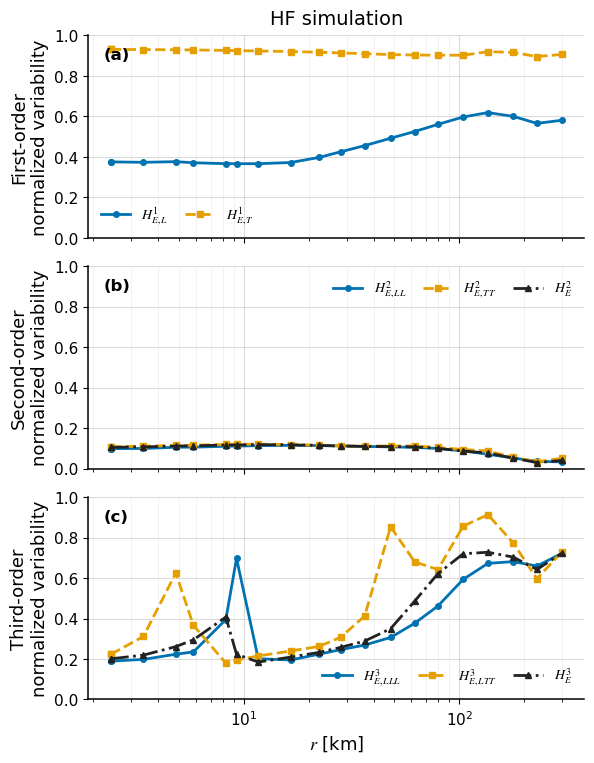

In [38]:
from pathlib import Path

import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt

# ============================================================
# Load HF result
# ============================================================
data_dir = Path(
    "/meddy/simingzhang/Data/Figure_SF3"
)

mat_path = (
    data_dir
    / "HF_Eulerian_gridBlock_all_orders.mat"
)

if not mat_path.exists():
    raise FileNotFoundError(
        f"File not found:\n{mat_path}"
    )

HF = sio.loadmat(
    mat_path,
    squeeze_me=True
)

print("Loaded:", mat_path)
print("Available variables:")
print([
    key for key in HF.keys()
    if not key.startswith("__")
])

# ============================================================
# Separation coordinate
# ============================================================
r_km = np.asarray(
    HF["r_actual"],
    dtype=float
).squeeze() / 1000.0

# ============================================================
# Figure style
# ============================================================
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "mathtext.fontset": "stix",
    "axes.linewidth": 1.1,
})

COLOR_LONGITUDINAL = "#0072B2"
COLOR_TRANSVERSE = "#E69F00"
COLOR_TOTAL = "#222222"

# ============================================================
# Plot helper
# ============================================================
def plot_H(
    ax,
    r,
    values,
    color,
    label,
    linestyle="-",
    marker=None,
    linewidth=2.0
):
    values = np.asarray(
        values,
        dtype=float
    ).squeeze()

    valid = (
        np.isfinite(r)
        & np.isfinite(values)
        & (r > 0)
    )

    ax.semilogx(
        r[valid],
        values[valid],
        color=color,
        linestyle=linestyle,
        marker=marker,
        markersize=4,
        linewidth=linewidth,
        label=label
    )

# ============================================================
# Figure
# ============================================================
fig, axes = plt.subplots(
    3,
    1,
    figsize=(6.2, 8.0),
    sharex=True
)

fig.subplots_adjust(
    left=0.16,
    right=0.96,
    bottom=0.10,
    top=0.93,
    hspace=0.14
)

# ------------------------------------------------------------
# (a) First-order metrics
# ------------------------------------------------------------
plot_H(
    axes[0],
    r_km,
    HF["H1L"],
    COLOR_LONGITUDINAL,
    r"$H_{E,L}^{1}$",
    linestyle="-",
    marker="o"
)

plot_H(
    axes[0],
    r_km,
    HF["H1T"],
    COLOR_TRANSVERSE,
    r"$H_{E,T}^{1}$",
    linestyle="--",
    marker="s"
)

axes[0].set_ylabel(
    "First-order\nnormalized variability"
)

axes[0].set_title(
    "HF simulation",
    pad=8
)

# ------------------------------------------------------------
# (b) Second-order metrics
# ------------------------------------------------------------
plot_H(
    axes[1],
    r_km,
    HF["H2L"],
    COLOR_LONGITUDINAL,
    r"$H_{E,LL}^{2}$",
    linestyle="-",
    marker="o"
)

plot_H(
    axes[1],
    r_km,
    HF["H2T"],
    COLOR_TRANSVERSE,
    r"$H_{E,TT}^{2}$",
    linestyle="--",
    marker="s"
)

plot_H(
    axes[1],
    r_km,
    HF["H2"],
    COLOR_TOTAL,
    r"$H_E^{2}$",
    linestyle="-.",
    marker="^"
)

axes[1].set_ylabel(
    "Second-order\nnormalized variability"
)

# ------------------------------------------------------------
# (c) Third-order metrics
# ------------------------------------------------------------
plot_H(
    axes[2],
    r_km,
    HF["H3L"],
    COLOR_LONGITUDINAL,
    r"$H_{E,LLL}^{3}$",
    linestyle="-",
    marker="o"
)

plot_H(
    axes[2],
    r_km,
    HF["H3LTT"],
    COLOR_TRANSVERSE,
    r"$H_{E,LTT}^{3}$",
    linestyle="--",
    marker="s"
)

plot_H(
    axes[2],
    r_km,
    HF["H3"],
    COLOR_TOTAL,
    r"$H_E^{3}$",
    linestyle="-.",
    marker="^"
)

axes[2].set_ylabel(
    "Third-order\nnormalized variability"
)

axes[2].set_xlabel(
    r"$r$ [km]"
)

# ============================================================
# Common formatting
# ============================================================
panel_labels = [
    "(a)",
    "(b)",
    "(c)"
]

for ax, panel_label in zip(
    axes,
    panel_labels
):
    ax.set_ylim(0, 1.0)

    ax.set_yticks(
        np.arange(0, 1.01, 0.2)
    )

    ax.grid(
        True,
        which="major",
        color="0.82",
        linewidth=0.8,
        alpha=0.8
    )

    ax.grid(
        True,
        which="minor",
        axis="x",
        color="0.90",
        linewidth=0.5,
        alpha=0.7
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.text(
        0.03,
        0.94,
        panel_label,
        transform=ax.transAxes,
        fontsize=12,
        fontweight="bold",
        ha="left",
        va="top"
    )

    ax.legend(
        loc="best",
        frameon=False,
        ncol=3,
        handlelength=2.1,
        columnspacing=1.2
    )

# ============================================================
# Save
# ============================================================
figure_path = (
    data_dir
    / "Fig_HF_Eulerian_homogeneity_all_orders.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

print(f"Saved figure:\n{figure_path}")

plt.show()

# read fft-SF3

In [45]:
import scipy.io as sio

def load_mat_as_namespace(file_path):
   
    class DataNamespace:
        pass
    
    data = sio.loadmat(file_path)
    ns = DataNamespace()
    
    for key, value in data.items():
        if not key.startswith('__'):
            setattr(ns, key, value)
    
    return ns
import xarray as xr
import re

def read_th_variables_numeric_sorted(fname):
  
    # 
    ds = xr.open_dataset(fname)
    th_vars = [var for var in ds.data_vars if var.startswith('th')]
    
    def extract_number(var_name):
        match = re.search(r'th(\d+)', var_name)
        if match:
            return int(match.group(1))
        return 0  
    
    th_vars_sorted = sorted(th_vars, key=extract_number)
    Th_arrays = [ds[var].values for var in th_vars_sorted]
    ds.close()
    
    return Th_arrays, th_vars_sorted
Casemean='Hf'
ini='_rough'
fignum=8
# data_ns = load_mat_as_namespace(f'/meddy/simingzhang/Data/Figure_SF3/new_plot_Iceland_Bayesiankaiser_{ini}_{Casemean}.mat')
# data_ns = load_mat_as_namespace(f'/meddy/simingzhang/Data/Figure_SF3/new_plot_Iceland_Bayesiankaiser_{ini}_{Casemean}_no2pi.mat')
# data_ns = load_mat_as_namespace(f'/meddy/simingzhang/Data/Figure_SF3/new_plot_Iceland_Bayesiankaiser_{ini}_{Casemean}_lesspoint.mat')
data_ns = load_mat_as_namespace(f'/meddy/simingzhang/Data/Figure_SF3/new_plot_Iceland_Bayesiankaiser_{ini}_{Casemean}_lesspoint_modi_eul_ver2.mat')
r_E=data_ns.r_E
SF3_fft=data_ns.SF3_E

/home/simingzhang/anaconda3/lib/python3.12/site-packages/scipy/io/matlab/_mio.py:227: MatReadWarning: Duplicate variable name "None" in stream - replacing previous with new
Consider mio5.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)


Loaded:
/meddy/simingzhang/Data/Figure_SF3/HF_Eulerian_gridBlock_all_orders.mat

Available variables:
['r_requested', 'r_actual', 'sample_count', 'nblock_y', 'nblock_x', 'min_samples_per_block', 'min_valid_blocks', 'periodic', 'require_same_block', 'time_chunk', 'local_Dl', 'H_Dl', 'mean_Dl', 'std_Dl', 'rms_Dl', 'cancellation_ratio_Dl', 'nvalid_blocks_Dl', 'local_Dt', 'H_Dt', 'mean_Dt', 'std_Dt', 'rms_Dt', 'cancellation_ratio_Dt', 'nvalid_blocks_Dt', 'local_Dll', 'H_Dll', 'mean_Dll', 'std_Dll', 'rms_Dll', 'cancellation_ratio_Dll', 'nvalid_blocks_Dll', 'local_Dtt', 'H_Dtt', 'mean_Dtt', 'std_Dtt', 'rms_Dtt', 'cancellation_ratio_Dtt', 'nvalid_blocks_Dtt', 'local_D2', 'H_D2', 'mean_D2', 'std_D2', 'rms_D2', 'cancellation_ratio_D2', 'nvalid_blocks_D2', 'local_Dlll', 'H_Dlll', 'mean_Dlll', 'std_Dlll', 'rms_Dlll', 'cancellation_ratio_Dlll', 'nvalid_blocks_Dlll', 'local_Dltt', 'H_Dltt', 'mean_Dltt', 'std_Dltt', 'rms_Dltt', 'cancellation_ratio_Dltt', 'nvalid_blocks_Dltt', 'local_D3', 'H_D3', 'me

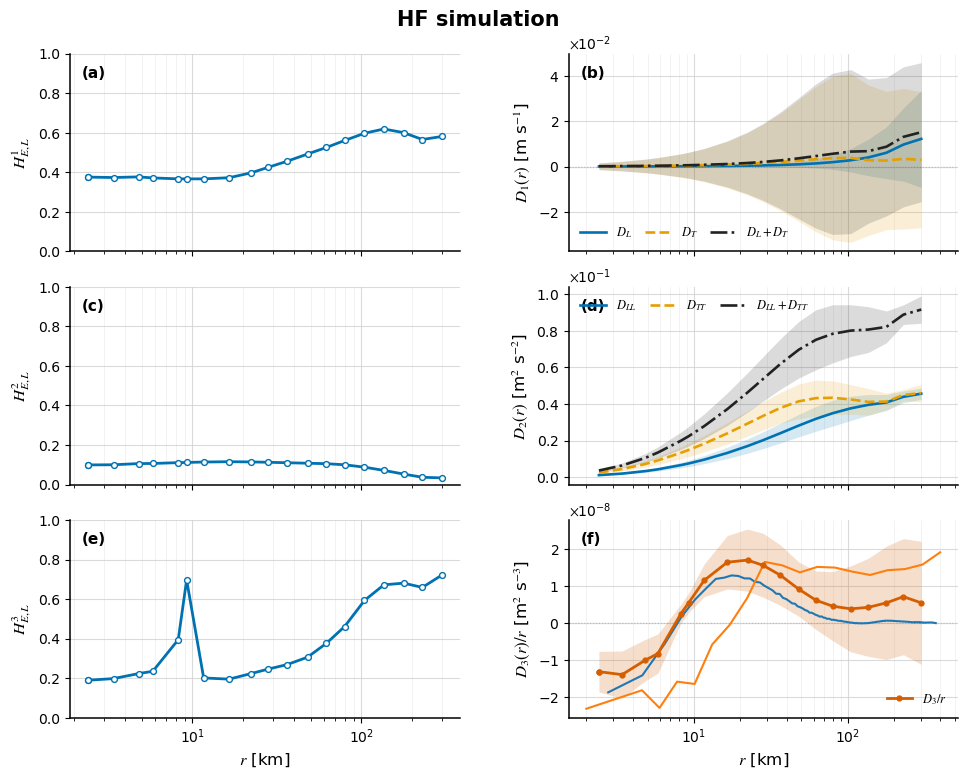

In [56]:
from pathlib import Path

import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt


# ============================================================
# Load HF Eulerian result
# ============================================================
data_dir = Path(
    "/meddy/simingzhang/Data/Figure_SF3"
)

mat_path = (
    data_dir
    / "HF_Eulerian_gridBlock_all_orders.mat"
)

if not mat_path.exists():
    raise FileNotFoundError(
        f"File not found:\n{mat_path}"
    )

HF = sio.loadmat(
    mat_path,
    squeeze_me=True
)

print(f"Loaded:\n{mat_path}")

print("\nAvailable variables:")
print([
    key
    for key in HF.keys()
    if not key.startswith("__")
])


# ============================================================
# Helper for loading one-dimensional variables
# ============================================================
def get_vector(data, name):
    if name not in data:
        raise KeyError(
            f"Variable '{name}' was not found."
        )

    return np.asarray(
        data[name],
        dtype=float
    ).squeeze()


def get_local(data, name):
    if name not in data:
        raise KeyError(
            f"Variable '{name}' was not found."
        )

    values = np.asarray(
        data[name],
        dtype=float
    )

    if values.ndim == 1:
        values = values[:, None]

    return values


# ============================================================
# Separation coordinate
# ============================================================
r_m = get_vector(
    HF,
    "r_actual"
)

r_km = r_m / 1000.0


# ============================================================
# Homogeneity metrics
# ============================================================
H1L = get_vector(HF, "H1L")
H2L = get_vector(HF, "H2L")
H3L = get_vector(HF, "H3L")


# ============================================================
# Local structure functions
#
# Shape:
#     (number of scales, number of spatial blocks)
# ============================================================
local_Dl = get_local(
    HF,
    "local_Dl"
)

local_Dt = get_local(
    HF,
    "local_Dt"
)

local_Dll = get_local(
    HF,
    "local_Dll"
)

local_Dtt = get_local(
    HF,
    "local_Dtt"
)

local_Dlll = get_local(
    HF,
    "local_Dlll"
)

local_Dltt = get_local(
    HF,
    "local_Dltt"
)


# ============================================================
# Construct combined quantities inside every block
# ============================================================
local_D1 = (
    local_Dl
    + local_Dt
)

local_D2 = (
    local_Dll
    + local_Dtt
)

local_D3 = (
    local_Dlll
    + local_Dltt
)


# ============================================================
# Spatial means and standard deviations across blocks
# ============================================================
def spatial_mean_std(local_values):
    """
    Calculate the equal-block spatial mean and standard deviation.

    local_values shape:
        (nscale, nblock)
    """
    mean_value = np.nanmean(
        local_values,
        axis=1
    )

    std_value = np.nanstd(
        local_values,
        axis=1,
        ddof=0
    )

    nvalid = np.sum(
        np.isfinite(local_values),
        axis=1
    )

    return mean_value, std_value, nvalid


# First-order components
Dl, Dl_std, Dl_nvalid = spatial_mean_std(
    local_Dl
)

Dt, Dt_std, Dt_nvalid = spatial_mean_std(
    local_Dt
)

D1, D1_std, D1_nvalid = spatial_mean_std(
    local_D1
)

# Second-order components
Dll, Dll_std, Dll_nvalid = spatial_mean_std(
    local_Dll
)

Dtt, Dtt_std, Dtt_nvalid = spatial_mean_std(
    local_Dtt
)

D2, D2_std, D2_nvalid = spatial_mean_std(
    local_D2
)

# Third-order total
D3, D3_std, D3_nvalid = spatial_mean_std(
    local_D3
)


# ============================================================
# Convert D3 and its standard deviation to D3/r
# ============================================================
D3_over_r = np.full_like(
    D3,
    np.nan,
    dtype=float
)

D3_over_r_std = np.full_like(
    D3_std,
    np.nan,
    dtype=float
)

valid_r = (
    np.isfinite(r_m)
    & (r_m > 0)
)

D3_over_r[valid_r] = (
    D3[valid_r]
    / r_m[valid_r]
)

D3_over_r_std[valid_r] = (
    D3_std[valid_r]
    / r_m[valid_r]
)


# ============================================================
# Display valid-block counts
# ============================================================
print("\nNumber of valid spatial blocks:")

for name, counts in [
    ("Dl", Dl_nvalid),
    ("Dt", Dt_nvalid),
    ("Dl + Dt", D1_nvalid),
    ("Dll", Dll_nvalid),
    ("Dtt", Dtt_nvalid),
    ("Dll + Dtt", D2_nvalid),
    ("D3", D3_nvalid),
]:
    print(
        f"{name:10s}: "
        f"min={np.nanmin(counts)}, "
        f"max={np.nanmax(counts)}"
    )


# ============================================================
# Figure style
# ============================================================
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "mathtext.fontset": "stix",
    "axes.linewidth": 1.1,
})

# Color-blind-friendly colors
COLOR_L = "#0072B2"
COLOR_T = "#E69F00"
COLOR_TOTAL = "#222222"
COLOR_D3 = "#D55E00"

# Shading opacity
SHADE_ALPHA = 0.16


# ============================================================
# Plot helpers
# ============================================================
def plot_with_shading(
    ax,
    x,
    mean,
    std,
    color,
    label,
    linestyle="-",
    marker=None,
    linewidth=1.9,
    alpha=SHADE_ALPHA,
    zorder=3
):
    """
    Plot spatial mean and ±1 standard deviation across blocks.
    """
    x = np.asarray(x, dtype=float)
    mean = np.asarray(mean, dtype=float)
    std = np.asarray(std, dtype=float)

    valid = (
        np.isfinite(x)
        & np.isfinite(mean)
        & np.isfinite(std)
        & (x > 0)
    )

    x_valid = x[valid]
    mean_valid = mean[valid]
    std_valid = std[valid]

    ax.fill_between(
        x_valid,
        mean_valid - std_valid,
        mean_valid + std_valid,
        color=color,
        alpha=alpha,
        linewidth=0,
        zorder=zorder - 1
    )

    ax.semilogx(
        x_valid,
        mean_valid,
        color=color,
        linestyle=linestyle,
        marker=marker,
        markersize=3.5,
        linewidth=linewidth,
        label=label,
        zorder=zorder
    )


def plot_H(
    ax,
    x,
    H,
    color,
    label
):
    """
    Plot one normalized spatial-variability metric.
    """
    x = np.asarray(x, dtype=float)
    H = np.asarray(H, dtype=float)

    valid = (
        np.isfinite(x)
        & np.isfinite(H)
        & (x > 0)
    )

    ax.semilogx(
        x[valid],
        H[valid],
        color=color,
        marker="o",
        markerfacecolor="white",
        markeredgecolor=color,
        markeredgewidth=1.0,
        markersize=4.2,
        linewidth=2.0,
        label=label,
        zorder=3
    )


# ============================================================
# Create figure
# ============================================================
fig, axes = plt.subplots(
    3,
    2,
    figsize=(10.2, 8.0),
    sharex="col"
)

fig.subplots_adjust(
    left=0.10,
    right=0.97,
    bottom=0.09,
    top=0.92,
    wspace=0.28,
    hspace=0.18
)

fig.suptitle(
    "HF simulation",
    fontsize=15,
    fontweight="bold",
    y=0.975
)


# ============================================================
# Row 1: first order
# ============================================================
plot_H(
    axes[0, 0],
    r_km,
    H1L,
    COLOR_L,
    r"$H_{E,L}^{1}$"
)

axes[0, 0].set_ylabel(
    r"$H_{E,L}^{1}$"
)

plot_with_shading(
    axes[0, 1],
    r_km,
    Dl,
    Dl_std,
    COLOR_L,
    r"$D_L$",
    linestyle="-",
    marker=None
)

plot_with_shading(
    axes[0, 1],
    r_km,
    Dt,
    Dt_std,
    COLOR_T,
    r"$D_T$",
    linestyle="--",
    marker=None
)

plot_with_shading(
    axes[0, 1],
    r_km,
    D1,
    D1_std,
    COLOR_TOTAL,
    r"$D_L+D_T$",
    linestyle="-.",
    marker=None
)

axes[0, 1].axhline(
    0,
    color="0.35",
    linewidth=0.8,
    linestyle=":",
    zorder=1
)

axes[0, 1].set_ylabel(
    r"$D_1(r)$ [m s$^{-1}$]"
)


# ============================================================
# Row 2: second order
# ============================================================
plot_H(
    axes[1, 0],
    r_km,
    H2L,
    COLOR_L,
    r"$H_{E,L}^{2}$"
)

axes[1, 0].set_ylabel(
    r"$H_{E,L}^{2}$"
)

plot_with_shading(
    axes[1, 1],
    r_km,
    Dll,
    Dll_std,
    COLOR_L,
    r"$D_{LL}$",
    linestyle="-"
)

plot_with_shading(
    axes[1, 1],
    r_km,
    Dtt,
    Dtt_std,
    COLOR_T,
    r"$D_{TT}$",
    linestyle="--"
)

plot_with_shading(
    axes[1, 1],
    r_km,
    D2,
    D2_std,
    COLOR_TOTAL,
    r"$D_{LL}+D_{TT}$",
    linestyle="-."
)

axes[1, 1].set_ylabel(
    r"$D_2(r)$ [m$^2$ s$^{-2}$]"
)


# ============================================================
# Row 3: third order
# ============================================================
plot_H(
    axes[2, 0],
    r_km,
    H3L,
    COLOR_L,
    r"$H_{E,L}^{3}$"
)

axes[2, 0].set_ylabel(
    r"$H_{E,L}^{3}$"
)

plot_with_shading(
    axes[2, 1],
    r_km,
    D3_over_r,
    D3_over_r_std,
    COLOR_D3,
    r"$D_3/r$",
    linestyle="-",
    marker="o",
    linewidth=2.0,
    alpha=0.20
)
axes[2, 1].semilogx(r_E*1e-3,SF3_fft/r_E)
axes[2, 1].semilogx(data_ns.dist_axis/1e3, data_ns.SF3_Lag289/data_ns.dist_axis)



axes[2, 1].axhline(
    0,
    color="0.35",
    linewidth=0.8,
    linestyle=":",
    zorder=1
)

axes[2, 1].set_ylabel(
    r"$D_3(r)/r$ [m$^2$ s$^{-3}$]"
)

axes[2, 0].set_xlabel(
    r"$r$ [km]"
)

axes[2, 1].set_xlabel(
    r"$r$ [km]"
)


# ============================================================
# Common formatting
# ============================================================
panel_labels = [
    "(a)", "(b)",
    "(c)", "(d)",
    "(e)", "(f)"
]

for index, ax in enumerate(axes.flat):

    ax.grid(
        True,
        which="major",
        color="0.82",
        linewidth=0.8,
        alpha=0.8
    )

    ax.grid(
        True,
        which="minor",
        axis="x",
        color="0.90",
        linewidth=0.5,
        alpha=0.7
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.text(
        0.03,
        0.94,
        panel_labels[index],
        transform=ax.transAxes,
        fontsize=11,
        fontweight="bold",
        ha="left",
        va="top"
    )


# H panels use the same range
for ax in axes[:, 0]:
    ax.set_ylim(0, 1.0)

    ax.set_yticks(
        np.arange(0, 1.01, 0.2)
    )


# ============================================================
# Legends
# ============================================================
axes[0, 1].legend(
    loc="best",
    frameon=False,
    ncol=3,
    handlelength=2.1,
    columnspacing=1.0
)

axes[1, 1].legend(
    loc="best",
    frameon=False,
    ncol=3,
    handlelength=2.1,
    columnspacing=1.0
)

axes[2, 1].legend(
    loc="best",
    frameon=False
)


# ============================================================
# Scientific notation
# ============================================================
for ax in axes[:, 1]:
    ax.ticklabel_format(
        axis="y",
        style="sci",
        scilimits=(0, 0),
        useMathText=True
    )


# ============================================================
# Save
# ============================================================
figure_path = (
    data_dir
    / "Fig_HF_Eulerian_H_SF_spatial_std.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

print(f"\nSaved figure:\n{figure_path}")

plt.show()